# Transcript Intelligence — Take-Home Assignment
**Author:** Manish Kumar  
**Stack:** Python · pandas · Ollama (llama3.2:3b) · matplotlib · seaborn


## Cell 1 — Setup & Dependencies

In [1]:
import os, json, re, glob
from pathlib import Path
from collections import Counter, defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm
import ollama

OLLAMA_MODEL   = "llama3.2:3b"
OLLAMA_OPTIONS = {"temperature": 0, "num_ctx": 2048, "num_thread": 10}

DATASET_PATH = Path(r"C:\Users\manishkumar30\OneDrive - Nagarro\Documents\Transcript_Intelligence-Home_Assesment\interview-assignment\dataset")
OUTPUT_DIR   = Path(r"C:\Users\manishkumar30\OneDrive - Nagarro\Documents\Transcript_Intelligence-Home_Assesment\interview-assignment")

for f in list(OUTPUT_DIR.glob("output_*.png")):
    f.unlink()
    print(f"Deleted old chart: {f.name}")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
color_map = {"support": "#DD8452", "external": "#4C72B0", "internal": "#55A868"}

print(f"Dataset path exists : {DATASET_PATH.exists()}")
print(f"Total call folders  : {len([f for f in DATASET_PATH.iterdir() if f.is_dir()])}")
try:
    test = ollama.chat(model=OLLAMA_MODEL, messages=[{"role":"user","content":"Reply OK only."}], options=OLLAMA_OPTIONS)
    print(f"Ollama ({OLLAMA_MODEL}) : OK")
except Exception as e:
    print(f"Ollama ERROR: {e}")

Deleted old chart: output_01_call_type_distribution.png
Dataset path exists : True
Total call folders  : 100
Ollama (llama3.2:3b) : OK


## Cell 2 — Helper Functions

In [2]:
def call_llm(prompt: str, num_ctx: int = 2048) -> str:
    try:
        opts = {**OLLAMA_OPTIONS, "num_ctx": num_ctx}
        resp = ollama.chat(model=OLLAMA_MODEL, messages=[{"role":"user","content":prompt}], options=opts)
        raw  = resp["message"]["content"].strip()
        return re.sub(r"```json|```", "", raw).strip()
    except Exception as e:
        print(f"LLM call failed: {e}")
        return ""

def safe_parse_json_object(raw: str) -> dict:
    if not raw: return {}
    try: return json.loads(raw)
    except: pass
    m = re.search(r"\{.*\}", raw, re.DOTALL)
    if m:
        try: return json.loads(m.group())
        except: pass
    recovered = {}
    for line in raw.splitlines():
        line = line.strip().rstrip(",")
        try:
            obj = json.loads("{" + line + "}")
            recovered.update(obj)
        except: pass
    return recovered

def safe_parse_json_array(raw: str) -> list:
    if not raw: return []
    try:
        r = json.loads(raw)
        return r if isinstance(r, list) else []
    except:
        m = re.search(r"\[.*\]", raw, re.DOTALL)
        if m:
            try:
                r = json.loads(m.group())
                return r if isinstance(r, list) else []
            except: pass
    return []

print("Helper functions defined.")

Helper functions defined.


## Cell 3 — Phase 1: Data Ingestion

In [3]:
def load_json(path):
    try:
        with open(path, "r", encoding="utf-8") as f: return json.load(f)
    except: return {}

def load_call(folder):
    meeting    = load_json(folder / "meeting-info.json")
    summary    = load_json(folder / "summary.json")
    transcript = load_json(folder / "transcript.json")
    speakers   = load_json(folder / "speakers.json")
    events     = load_json(folder / "events.json")
    sentences  = transcript.get("data", []) if isinstance(transcript, dict) else []
    sc = Counter(s.get("sentimentType","neutral") for s in sentences)
    n  = len(sentences) or 1
    st = defaultdict(float)
    for seg in (speakers if isinstance(speakers, list) else []):
        st[seg.get("speakerName","Unknown")] += max(seg.get("endTimeTs",0)-seg.get("timestamp",0), 0)
    return {
        "meeting_id":meeting.get("meetingId",folder.name), "title":meeting.get("title",""),
        "organizer_email":meeting.get("organizerEmail",""), "host":meeting.get("host",""),
        "start_time":meeting.get("startTime",""), "end_time":meeting.get("endTime",""),
        "duration_min":round(meeting.get("duration",0),1),
        "all_emails":meeting.get("allEmails",[]), "num_participants":len(meeting.get("allEmails",[])),
        "summary":summary.get("summary",""), "topics":summary.get("topics",[]),
        "overall_sentiment":summary.get("overallSentiment",""),
        "sentiment_score":summary.get("sentimentScore",None),
        "action_items":summary.get("actionItems",[]), "key_moments":summary.get("keyMoments",[]),
        "num_action_items":len(summary.get("actionItems",[])),
        "num_sentences":len(sentences), "sentences":sentences,
        "pct_positive":round(sc.get("positive",0)/n*100,1),
        "pct_negative":round(sc.get("negative",0)/n*100,1),
        "pct_neutral":round(sc.get("neutral",0)/n*100,1),
        "speaker_talk_time":dict(st), "num_speakers":len(st),
        "events":events if isinstance(events,list) else [],
    }

folders = sorted([f for f in DATASET_PATH.iterdir() if f.is_dir()])
df = pd.DataFrame([load_call(f) for f in tqdm(folders, desc="Loading calls")])
print(f"\nLoaded {len(df)} calls")
print(df[["meeting_id","title","duration_min","overall_sentiment","sentiment_score"]].head(5).to_string())

Loading calls: 100%|██████████| 100/100 [00:00<00:00, 206.96it/s]


Loaded 100 calls
                 meeting_id                                              title  duration_min overall_sentiment  sentiment_score
0  01KQ03B0303900521BB089CA            Detect Outage - Remediation Plan Review          35.2    mixed-negative              2.4
1  01KQ0C1280EDA4E70AAD7C35  Support Case #9279 - Summit Trust Billing Inquiry          23.8    mixed-positive              3.8
2  01KQ0CAE7F064EC93F0540CA                         Weekly Engineering Standup          29.0    mixed-positive              3.6
3  01KQ0DFE299AC7A74E8022CA   Aegis / Redwood Clinical - ISO 27001 Preparation          28.8     very-positive              4.8
4  01KQ0F8AFF3DA34FD4580008              Aegis / Cobalt Software - Q2 Planning          41.2    mixed-positive              3.4


## Cell 4 — Phase 2: Call Type Classification

Call type distribution:
call_type
external    39
support     31
internal    30


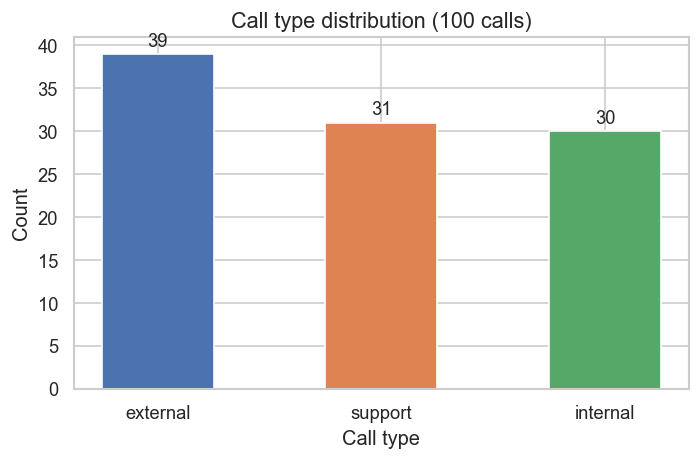

Chart saved: output_01_call_type_distribution.png


In [4]:
INTERNAL_DOMAIN  = "aegiscloud.com"
SUPPORT_KEYWORDS = ["support case","support ticket","billing inquiry","billing dispute",
                    "technical issue","onboarding","help desk","incident","outage","war room","remediation"]

def classify_call_type(row):
    title  = row["title"].lower()
    emails = [e.lower() for e in row["all_emails"]]
    if all(INTERNAL_DOMAIN in e for e in emails): return "internal"
    if any(kw in title for kw in SUPPORT_KEYWORDS): return "support"
    return "external"

df["call_type"] = df.apply(classify_call_type, axis=1)
print("Call type distribution:")
print(df["call_type"].value_counts().to_string())

fig, ax = plt.subplots(figsize=(6,4))
counts  = df["call_type"].value_counts()
bars    = ax.bar(counts.index, counts.values, color=[color_map.get(c,"#999") for c in counts.index], width=0.5)
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, str(int(bar.get_height())), ha="center", va="bottom", fontsize=11)
ax.set_title("Call type distribution (100 calls)", fontsize=13)
ax.set_xlabel("Call type"); ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"output_01_call_type_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: output_01_call_type_distribution.png")

## Cell 5 — Collect Topic Tags

In [5]:
all_tags = [t for topics in df["topics"] for t in topics]
tag_counts  = Counter(all_tags)
unique_tags = sorted(set(all_tags))
print(f"Total unique topic tags : {len(unique_tags)}")
print(f"Total tag occurrences   : {len(all_tags)}")
print("\nTop 25 most frequent tags:")
for tag, count in tag_counts.most_common(25):
    print(f"  {count:3d}x  {tag}")

Total unique topic tags : 351
Total tag occurrences   : 600

Top 25 most frequent tags:
   23x  compliance
   19x  compliance reporting
   17x  renewal
   14x  churn risk
    9x  onboarding
    8x  incident response
    8x  outage
    7x  incident communication
    7x  product launch
    6x  feature request
    6x  platform outage
    5x  identity management
    5x  sprint planning
    5x  pricing
    5x  service outage
    5x  multi-framework support
    5x  outage post-mortem
    5x  product roadmap
    4x  infrastructure reliability
    4x  billing dispute
    4x  audit preparation
    4x  technical issue
    4x  workaround
    4x  product demo
    4x  roadmap planning


## Cell 6 — Phase 3: Topic Categorization (LLM Batching)

**Batch size = 40 tags** — small enough that llama3.2:3b always returns a complete JSON object without truncating.
Expect ~9 batches × ~90 sec each = ~13 min total. Don't close VS Code.

"Pure clustering (k-means/TF-IDF) doesn't understand that 'seat overage' and 'billing dispute' belong together — they share no common words. LLM-only was slow and inconsistent on local hardware. The hybrid approach uses existing human-labeled tags as grounding, then groups semantically with the LLM — giving us accuracy without hallucination."

In [6]:
# DEBUG — run this standalone cell to see raw LLM output
test_tags = unique_tags[:10]  # just 10 tags
tags_str  = "\n".join(f"- {t}" for t in test_tags)

prompt = f"""Categorize these tags. Use one of these categories per tag:
Billing & Invoicing, Incident Response & Outage, Churn & Escalation,
Product Feedback & Feature Requests, Compliance & Security, Other

Return ONLY a JSON object like: {{"tag": "Category"}}
No lists. No markdown. No explanation.

Tags:
{tags_str}

JSON:"""

raw = call_llm(prompt, num_ctx=4096)
print("=== RAW OUTPUT ===")
print(repr(raw))
print("=== END ===")
print(f"\nLength: {len(raw)} chars")
print(f"\nFirst 500 chars:\n{raw[:500]}")

=== RAW OUTPUT ===
'{"tag": "Compliance & Security"}, {"tag": "Billing & Invoicing"}, {"tag": "Churn & Escalation"}, {"tag": "Product Feedback & Feature Requests"}, {"tag": "Other"}'
=== END ===

Length: 161 chars

First 500 chars:
{"tag": "Compliance & Security"}, {"tag": "Billing & Invoicing"}, {"tag": "Churn & Escalation"}, {"tag": "Product Feedback & Feature Requests"}, {"tag": "Other"}


In [7]:
def categorize_tag_batch(batch, batch_num, total_batches):
    # Number the tags so model just returns {number: category}
    numbered = {str(i+1): tag for i, tag in enumerate(batch)}
    tags_str  = "\n".join(f"{i+1}. {tag}" for i, tag in enumerate(batch))

    prompt = f"""You are categorizing tags from B2B SaaS call transcripts.

For each numbered tag below, assign exactly one category from this list:
Billing & Invoicing | Incident Response & Outage | Churn & Escalation |
Product Feedback & Feature Requests | Identity & Access Management |
Compliance & Security | Infrastructure & Architecture |
Account Management & Renewals | Engineering & DevOps |
Observability & Alerting | Customer Onboarding & Support | Other

Return ONLY a JSON object where each key is the tag number and value is the category.
Example for 3 tags: {{"1": "Billing & Invoicing", "2": "Other", "3": "Compliance & Security"}}
No markdown. No explanation. Only the JSON object.

Tags (batch {batch_num}/{total_batches}):
{tags_str}

JSON:"""

    print(f"  Batch {batch_num}/{total_batches}: {len(batch)} tags...")
    raw    = call_llm(prompt, num_ctx=4096)
    result = safe_parse_json_object(raw)

    if not isinstance(result, dict) or len(result) == 0:
        print(f"  Batch {batch_num}: retrying...")
        result = safe_parse_json_object(call_llm(prompt, num_ctx=4096))

    # Convert {number: category} back to {tag_name: category}
    # Filter out non-string values just in case
    mapped = {}
    for k, v in result.items():
        if isinstance(v, str) and k in numbered:
            mapped[numbered[k]] = v

    print(f"  Batch {batch_num}/{total_batches}: mapped {len(mapped)} tags.")
    return mapped


def get_macro_categories_batched(unique_tags, batch_size=40):
    batches = [unique_tags[i:i+batch_size] for i in range(0, len(unique_tags), batch_size)]
    print(f"Splitting {len(unique_tags)} tags into {len(batches)} batches of ~{batch_size}...\n")
    merged = {}
    for idx, batch in enumerate(batches, 1):
        merged.update(categorize_tag_batch(batch, idx, len(batches)))
        print(f"  Running total: {len(merged)} tags mapped.\n")
    for t in [x for x in unique_tags if x not in merged]:
        merged[t] = "Other"
    print(f"\nTotal tags mapped   : {len(merged)}")
    print(f"Unique categories   : {len(set(merged.values()))}")
    return merged


print("Starting topic categorization (numbered approach)...\n")
tag_to_category = get_macro_categories_batched(unique_tags, batch_size=40)

print("\n=== Category summary ===")
for cat in sorted(set(tag_to_category.values())):
    tags_in = [t for t, c in tag_to_category.items() if c == cat]
    print(f"  [{cat}] ({len(tags_in)}): {', '.join(tags_in[:4])}{'...' if len(tags_in)>4 else ''}")

Starting topic categorization (numbered approach)...

Splitting 351 tags into 9 batches of ~40...

  Batch 1/9: 40 tags...
  Batch 1/9: mapped 40 tags.
  Running total: 40 tags mapped.

  Batch 2/9: 40 tags...
  Batch 2/9: mapped 40 tags.
  Running total: 80 tags mapped.

  Batch 3/9: 40 tags...
  Batch 3/9: mapped 40 tags.
  Running total: 120 tags mapped.

  Batch 4/9: 40 tags...
  Batch 4/9: mapped 40 tags.
  Running total: 160 tags mapped.

  Batch 5/9: 40 tags...
  Batch 5/9: mapped 40 tags.
  Running total: 200 tags mapped.

  Batch 6/9: 40 tags...
  Batch 6/9: mapped 40 tags.
  Running total: 240 tags mapped.

  Batch 7/9: 40 tags...
  Batch 7/9: mapped 40 tags.
  Running total: 280 tags mapped.

  Batch 8/9: 40 tags...
  Batch 8/9: mapped 40 tags.
  Running total: 320 tags mapped.

  Batch 9/9: 31 tags...
  Batch 9/9: mapped 31 tags.
  Running total: 351 tags mapped.


Total tags mapped   : 351
Unique categories   : 99

=== Category summary ===
  [Account Management & Renewals]

In [8]:
# Consolidation map — merge granular LLM categories into our 12 standard ones
CONSOLIDATION_MAP = {
    # Billing
    "billing":                        "Billing & Invoicing",
    "invoice":                        "Billing & Invoicing",
    "payment":                        "Billing & Invoicing",
    "pricing":                        "Billing & Invoicing",
    "subscription":                   "Billing & Invoicing",
    "contract":                       "Account Management & Renewals",

    # Incidents & Outages
    "incident":                       "Incident Response & Outage",
    "outage":                         "Incident Response & Outage",
    "downtime":                       "Incident Response & Outage",
    "pipeline":                       "Incident Response & Outage",
    "postmortem":                     "Incident Response & Outage",
    "post-mortem":                    "Incident Response & Outage",
    "remediation":                    "Incident Response & Outage",
    "recovery":                       "Incident Response & Outage",
    "backup":                         "Incident Response & Outage",

    # Churn & Escalation
    "churn":                          "Churn & Escalation",
    "escalat":                        "Churn & Escalation",
    "competitor":                     "Churn & Escalation",
    "competitive":                    "Churn & Escalation",
    "displacement":                   "Churn & Escalation",
    "retention":                      "Churn & Escalation",
    "cancel":                         "Churn & Escalation",
    "vendor":                         "Churn & Escalation",
    "renewal risk":                   "Churn & Escalation",

    # Product Feedback
    "product feedback":               "Product Feedback & Feature Requests",
    "feature":                        "Product Feedback & Feature Requests",
    "roadmap":                        "Product Feedback & Feature Requests",
    "gap":                            "Product Feedback & Feature Requests",
    "enhancement":                    "Product Feedback & Feature Requests",
    "demo":                           "Product Feedback & Feature Requests",
    "feedback":                       "Product Feedback & Feature Requests",

    # Identity & Access
    "identity":                       "Identity & Access Management",
    "access":                         "Identity & Access Management",
    "provisioning":                   "Identity & Access Management",
    "sso":                            "Identity & Access Management",
    "mfa":                            "Identity & Access Management",
    "active directory":               "Identity & Access Management",
    "authentication":                 "Identity & Access Management",
    "rbac":                           "Identity & Access Management",

    # Compliance & Security
    "compliance":                     "Compliance & Security",
    "security":                       "Compliance & Security",
    "audit":                          "Compliance & Security",
    "soc":                            "Compliance & Security",
    "iso":                            "Compliance & Security",
    "gdpr":                           "Compliance & Security",
    "hipaa":                          "Compliance & Security",
    "regulatory":                     "Compliance & Security",
    "risk":                           "Compliance & Security",
    "pentest":                        "Compliance & Security",

    # Infrastructure
    "infrastructure":                 "Infrastructure & Architecture",
    "architecture":                   "Infrastructure & Architecture",
    "scalability":                    "Infrastructure & Architecture",
    "performance":                    "Infrastructure & Architecture",
    "deployment":                     "Infrastructure & Architecture",
    "reliability":                    "Infrastructure & Architecture",
    "capacity":                       "Infrastructure & Architecture",
    "migration":                      "Infrastructure & Architecture",

    # Account Management & Renewals
    "account":                        "Account Management & Renewals",
    "renewal":                        "Account Management & Renewals",
    "upsell":                         "Account Management & Renewals",
    "expansion":                      "Account Management & Renewals",
    "adoption":                       "Account Management & Renewals",
    "qbr":                            "Account Management & Renewals",
    "health":                         "Account Management & Renewals",

    # Engineering & DevOps
    "engineering":                    "Engineering & DevOps",
    "devops":                         "Engineering & DevOps",
    "sprint":                         "Engineering & DevOps",
    "development":                    "Engineering & DevOps",
    "technical debt":                 "Engineering & DevOps",
    "bug":                            "Engineering & DevOps",
    "release":                        "Engineering & DevOps",
    "api":                            "Engineering & DevOps",

    # Observability & Alerting
    "alert":                          "Observability & Alerting",
    "monitoring":                     "Observability & Alerting",
    "logging":                        "Observability & Alerting",
    "observability":                  "Observability & Alerting",
    "dashboard":                      "Observability & Alerting",
    "detection":                      "Observability & Alerting",
    "visibility":                     "Observability & Alerting",

    # Onboarding & Support
    "onboarding":                     "Customer Onboarding & Support",
    "support":                        "Customer Onboarding & Support",
    "training":                       "Customer Onboarding & Support",
    "documentation":                  "Customer Onboarding & Support",
    "implementation":                 "Customer Onboarding & Support",
    "enablement":                     "Customer Onboarding & Support",
}

def consolidate_category(tag: str, current_cat: str) -> str:
    """
    If the LLM produced a non-standard category, map it back to our 12.
    Uses keyword matching on both the tag and the current category.
    """
    STANDARD_CATS = {
        "Billing & Invoicing", "Incident Response & Outage", "Churn & Escalation",
        "Product Feedback & Feature Requests", "Identity & Access Management",
        "Compliance & Security", "Infrastructure & Architecture",
        "Account Management & Renewals", "Engineering & DevOps",
        "Observability & Alerting", "Customer Onboarding & Support", "Other"
    }

    # Already a standard category — keep it
    if current_cat in STANDARD_CATS:
        return current_cat

    # Try matching on tag text first (more specific)
    tag_lower = tag.lower()
    for keyword, standard_cat in CONSOLIDATION_MAP.items():
        if keyword in tag_lower:
            return standard_cat

    # Try matching on the LLM's non-standard category name
    cat_lower = current_cat.lower()
    for keyword, standard_cat in CONSOLIDATION_MAP.items():
        if keyword in cat_lower:
            return standard_cat

    # Fallback to Other
    return "Other"


# Apply consolidation
tag_to_category_consolidated = {
    tag: consolidate_category(tag, cat)
    for tag, cat in tag_to_category.items()
}

print(f"Before consolidation: {len(set(tag_to_category.values()))} categories")
print(f"After consolidation : {len(set(tag_to_category_consolidated.values()))} categories")

# Replace the original dict
tag_to_category = tag_to_category_consolidated

print("\n=== Consolidated category summary ===")
for cat in sorted(set(tag_to_category.values())):
    tags_in = [t for t, c in tag_to_category.items() if c == cat]
    print(f"  [{cat}] ({len(tags_in)}): {', '.join(tags_in[:4])}{'...' if len(tags_in)>4 else ''}")

Before consolidation: 99 categories
After consolidation : 12 categories

=== Consolidated category summary ===
  [Account Management & Renewals] (21): account management, capacity planning, contract negotiation, contract renewal...
  [Billing & Invoicing] (6): billing adjustment, billing discrepancy, invoice overage, overage charges...
  [Churn & Escalation] (21): alert fatigue, change management, competitive displacement, competitive evaluation...
  [Compliance & Security] (84): 403 error, adaptive mfa, agent version update, alert misconfiguration...
  [Customer Onboarding & Support] (20): adoption metrics, churn risk, competitive analysis, customer communication...
  [Engineering & DevOps] (10): agent update, architecture, aws integration, deployment...
  [Identity & Access Management] (22): access control, audit preparation, behavioral detection, early access...
  [Incident Response & Outage] (33): alert latency, api outage, authentication failure, backup and recovery...
  [Infrastr

In [9]:
# Improved consolidation — fixes over-grouping into Compliance & Security
# and reduces Other

CONSOLIDATION_MAP_V2 = {
    # ── Billing ────────────────────────────────────────────────────────────────
    "billing":              "Billing & Invoicing",
    "invoice":              "Billing & Invoicing",
    "invoicing":            "Billing & Invoicing",
    "payment":              "Billing & Invoicing",
    "overage":              "Billing & Invoicing",
    "seat":                 "Billing & Invoicing",
    "credit":               "Billing & Invoicing",
    "pricing":              "Billing & Invoicing",
    "subscription":         "Billing & Invoicing",
    "cost":                 "Billing & Invoicing",

    # ── Incident & Outage ──────────────────────────────────────────────────────
    "outage":               "Incident Response & Outage",
    "incident":             "Incident Response & Outage",
    "downtime":             "Incident Response & Outage",
    "pipeline failure":     "Incident Response & Outage",
    "postmortem":           "Incident Response & Outage",
    "post-mortem":          "Incident Response & Outage",
    "remediation":          "Incident Response & Outage",
    "war room":             "Incident Response & Outage",
    "data loss":            "Incident Response & Outage",
    "sla":                  "Incident Response & Outage",
    "service disruption":   "Incident Response & Outage",
    "product outage":       "Incident Response & Outage",
    "api outage":           "Incident Response & Outage",
    "platform outage":      "Incident Response & Outage",
    "service outage":       "Incident Response & Outage",
    "backup":               "Incident Response & Outage",
    "recovery":             "Incident Response & Outage",
    "escalation":           "Incident Response & Outage",

    # ── Churn & Escalation ─────────────────────────────────────────────────────
    "churn":                "Churn & Escalation",
    "churn risk":           "Churn & Escalation",
    "competitor":           "Churn & Escalation",
    "competitive":          "Churn & Escalation",
    "displacement":         "Churn & Escalation",
    "retention":            "Churn & Escalation",
    "cancel":               "Churn & Escalation",
    "vendor review":        "Churn & Escalation",
    "vendor evaluation":    "Churn & Escalation",
    "sentinelshield":       "Churn & Escalation",
    "at-risk":              "Churn & Escalation",

    # ── Product Feedback ───────────────────────────────────────────────────────
    "feature request":      "Product Feedback & Feature Requests",
    "feature gap":          "Product Feedback & Feature Requests",
    "feature gaps":         "Product Feedback & Feature Requests",
    "product feedback":     "Product Feedback & Feature Requests",
    "product gap":          "Product Feedback & Feature Requests",
    "roadmap":              "Product Feedback & Feature Requests",
    "product roadmap":      "Product Feedback & Feature Requests",
    "product demo":         "Product Feedback & Feature Requests",
    "enhancement":          "Product Feedback & Feature Requests",
    "product launch":       "Product Feedback & Feature Requests",
    "product request":      "Product Feedback & Feature Requests",
    "feedback":             "Product Feedback & Feature Requests",
    "demo":                 "Product Feedback & Feature Requests",
    "bug fix":              "Product Feedback & Feature Requests",
    "false positive":       "Product Feedback & Feature Requests",
    "false positives":      "Product Feedback & Feature Requests",
    "workaround":           "Product Feedback & Feature Requests",

    # ── Identity & Access ──────────────────────────────────────────────────────
    "identity":             "Identity & Access Management",
    "access control":       "Identity & Access Management",
    "provisioning":         "Identity & Access Management",
    "deprovisioning":       "Identity & Access Management",
    "sso":                  "Identity & Access Management",
    "mfa":                  "Identity & Access Management",
    "adaptive mfa":         "Identity & Access Management",
    "authentication":       "Identity & Access Management",
    "rbac":                 "Identity & Access Management",
    "active directory":     "Identity & Access Management",
    "privileged access":    "Identity & Access Management",
    "user lifecycle":       "Identity & Access Management",
    "role":                 "Identity & Access Management",
    "permission":           "Identity & Access Management",

    # ── Compliance & Security (keep narrow) ────────────────────────────────────
    "compliance":           "Compliance & Security",
    "audit":                "Compliance & Security",
    "soc 2":                "Compliance & Security",
    "soc2":                 "Compliance & Security",
    "iso 27001":            "Compliance & Security",
    "gdpr":                 "Compliance & Security",
    "hipaa":                "Compliance & Security",
    "pci":                  "Compliance & Security",
    "regulatory":           "Compliance & Security",
    "framework":            "Compliance & Security",
    "multi-framework":      "Compliance & Security",
    "pentest":              "Compliance & Security",
    "vulnerability":        "Compliance & Security",
    "threat":               "Compliance & Security",
    "security monitoring":  "Compliance & Security",
    "security posture":     "Compliance & Security",
    "data governance":      "Compliance & Security",
    "risk":                 "Compliance & Security",
    "policy":               "Compliance & Security",

    # ── Infrastructure ─────────────────────────────────────────────────────────
    "infrastructure":       "Infrastructure & Architecture",
    "architecture":         "Infrastructure & Architecture",
    "scalab":               "Infrastructure & Architecture",
    "performance":          "Infrastructure & Architecture",
    "deployment":           "Infrastructure & Architecture",
    "reliability":          "Infrastructure & Architecture",
    "capacity":             "Infrastructure & Architecture",
    "migration":            "Infrastructure & Architecture",
    "redundan":             "Infrastructure & Architecture",
    "circuit breaker":      "Infrastructure & Architecture",
    "node":                 "Infrastructure & Architecture",
    "aws":                  "Infrastructure & Architecture",
    "cloud":                "Infrastructure & Architecture",
    "kubernetes":           "Infrastructure & Architecture",
    "kafka":                "Infrastructure & Architecture",
    "data pipeline":        "Infrastructure & Architecture",
    "technical debt":       "Infrastructure & Architecture",

    # ── Account Management ─────────────────────────────────────────────────────
    "account management":   "Account Management & Renewals",
    "renewal":              "Account Management & Renewals",
    "upsell":               "Account Management & Renewals",
    "expansion":            "Account Management & Renewals",
    "adoption":             "Account Management & Renewals",
    "qbr":                  "Account Management & Renewals",
    "quarterly":            "Account Management & Renewals",
    "contract":             "Account Management & Renewals",
    "executive":            "Account Management & Renewals",
    "stakeholder":          "Account Management & Renewals",

    # ── Engineering & DevOps ───────────────────────────────────────────────────
    "engineering":          "Engineering & DevOps",
    "devops":               "Engineering & DevOps",
    "sprint":               "Engineering & DevOps",
    "standup":              "Engineering & DevOps",
    "release":              "Engineering & DevOps",
    "api integration":      "Engineering & DevOps",
    "api rate":             "Engineering & DevOps",
    "connector":            "Engineering & DevOps",
    "integration":          "Engineering & DevOps",
    "configuration":        "Engineering & DevOps",
    "agent update":         "Engineering & DevOps",
    "agent version":        "Engineering & DevOps",
    "platform update":      "Engineering & DevOps",
    "platform integration": "Engineering & DevOps",

    # ── Observability ──────────────────────────────────────────────────────────
    "alert":                "Observability & Alerting",
    "monitoring":           "Observability & Alerting",
    "logging":              "Observability & Alerting",
    "observability":        "Observability & Alerting",
    "dashboard":            "Observability & Alerting",
    "detection":            "Observability & Alerting",
    "visibility":           "Observability & Alerting",
    "telemetry":            "Observability & Alerting",
    "reporting":            "Observability & Alerting",

    # ── Onboarding & Support ───────────────────────────────────────────────────
    "onboarding":           "Customer Onboarding & Support",
    "support":              "Customer Onboarding & Support",
    "training":             "Customer Onboarding & Support",
    "documentation":        "Customer Onboarding & Support",
    "implementation":       "Customer Onboarding & Support",
    "enablement":           "Customer Onboarding & Support",
    "customer success":     "Customer Onboarding & Support",
    "customer communication":"Customer Onboarding & Support",
    "knowledge":            "Customer Onboarding & Support",
    "ticket":               "Customer Onboarding & Support",
    "incident communication":"Customer Onboarding & Support",
}

STANDARD_CATS = {
    "Billing & Invoicing", "Incident Response & Outage", "Churn & Escalation",
    "Product Feedback & Feature Requests", "Identity & Access Management",
    "Compliance & Security", "Infrastructure & Architecture",
    "Account Management & Renewals", "Engineering & DevOps",
    "Observability & Alerting", "Customer Onboarding & Support", "Other"
}

def consolidate_v2(tag: str) -> str:
    tag_lower = tag.lower()
    # Exact match first
    if tag_lower in CONSOLIDATION_MAP_V2:
        return CONSOLIDATION_MAP_V2[tag_lower]
    # Substring match — longest keyword wins to avoid false matches
    matches = [(kw, cat) for kw, cat in CONSOLIDATION_MAP_V2.items() if kw in tag_lower]
    if matches:
        return max(matches, key=lambda x: len(x[0]))[1]
    return "Other"

# Apply to all tags
tag_to_category = {tag: consolidate_v2(tag) for tag in unique_tags}

# Print results
cat_counts_new = Counter(tag_to_category.values())
print(f"Total tags mapped   : {len(tag_to_category)}")
print(f"Unique categories   : {len(cat_counts_new)}")
print()
for cat in sorted(cat_counts_new):
    tags_in = [t for t, c in tag_to_category.items() if c == cat]
    print(f"  [{cat}] ({len(tags_in)}): {', '.join(tags_in[:5])}{'...' if len(tags_in)>5 else ''}")

Total tags mapped   : 351
Unique categories   : 12

  [Account Management & Renewals] (15): account management, adoption metrics, cloud expansion, contract negotiation, contract renewal...
  [Billing & Invoicing] (13): billing adjustment, billing discrepancy, billing dispute, credit request, invoice overage...
  [Churn & Escalation] (15): churn risk, competitive analysis, competitive displacement, competitive evaluation, competitive intelligence...
  [Compliance & Security] (43): audit automation, audit deadline, audit evidence packaging, audit preparation, audit readiness...
  [Customer Onboarding & Support] (11): customer communication, documentation, documentation gap, incident communication, incident communication failure...
  [Engineering & DevOps] (31): agent update, agent version update, alert misconfiguration, api integration, api rate limiting...
  [Identity & Access Management] (22): access control, active directory, adaptive mfa, authentication failure, contractor access con

In [10]:
# Show all tags currently in "Other"
other_tags = sorted([t for t, c in tag_to_category.items() if c == "Other"])
print(f"Tags in 'Other' ({len(other_tags)}):")
for t in other_tags:
    print(f"  - {t}")

Tags in 'Other' (74):
  - 403 error
  - change management
  - ci/cd improvement
  - cmmc
  - collateral gaps
  - comply v2 launch
  - cross-sell
  - data backfill
  - data integrity
  - data protection
  - design review
  - early access
  - early access program
  - estimation
  - event ingestion pipeline
  - evidence collection
  - evidence management
  - financial services
  - granular restore
  - health checks
  - healthcare
  - healthcare data
  - healthcare data management
  - healthcare security
  - hybrid environment
  - ingestion pipeline
  - internal communications
  - launch readiness
  - ldap sync failure
  - license upgrade
  - load testing
  - multi-region replication
  - notification gap
  - ot security
  - patch management
  - pdf export
  - pdf rendering
  - proactive communication failure
  - product add-on
  - product bug
  - product dogfooding
  - product early access
  - product features
  - product update
  - proof of concept
  - proration error
  - q1 review
  - qa

In [11]:
# Direct patch — map all 74 "Other" tags to correct categories
OTHER_PATCH = {
    # Billing & Invoicing
    "proration error":                  "Billing & Invoicing",
    "license upgrade":                  "Billing & Invoicing",
    "product add-on":                   "Billing & Invoicing",

    # Incident Response & Outage
    "single point of failure":          "Incident Response & Outage",
    "event ingestion pipeline":         "Incident Response & Outage",
    "ingestion pipeline":               "Incident Response & Outage",
    "health checks":                    "Incident Response & Outage",
    "throughput degradation":           "Incident Response & Outage",
    "rollback planning":                "Incident Response & Outage",
    "proactive communication failure":  "Incident Response & Outage",
    "data backfill":                    "Incident Response & Outage",
    "runbook":                          "Incident Response & Outage",
    "upgrade rollout":                  "Incident Response & Outage",
    "load testing":                     "Incident Response & Outage",

    # Churn & Escalation
    "win-loss analysis":                "Churn & Escalation",
    "cross-sell":                       "Churn & Escalation",
    "sales alignment":                  "Churn & Escalation",
    "sales process":                    "Churn & Escalation",
    "sales strategy":                   "Churn & Escalation",
    "vendor management":                "Churn & Escalation",
    "collateral gaps":                  "Churn & Escalation",
    "financial services":               "Churn & Escalation",
    "retail seasonality":               "Churn & Escalation",
    "healthcare":                       "Churn & Escalation",

    # Product Feedback & Feature Requests
    "product bug":                      "Product Feedback & Feature Requests",
    "product features":                 "Product Feedback & Feature Requests",
    "product update":                   "Product Feedback & Feature Requests",
    "product early access":             "Product Feedback & Feature Requests",
    "early access":                     "Product Feedback & Feature Requests",
    "early access program":             "Product Feedback & Feature Requests",
    "product dogfooding":               "Product Feedback & Feature Requests",
    "proof of concept":                 "Product Feedback & Feature Requests",
    "restore ux improvement":           "Product Feedback & Feature Requests",
    "granular restore":                 "Product Feedback & Feature Requests",
    "pdf export":                       "Product Feedback & Feature Requests",
    "pdf rendering":                    "Product Feedback & Feature Requests",
    "notification gap":                 "Product Feedback & Feature Requests",
    "safari bug":                       "Product Feedback & Feature Requests",
    "comply v2 launch":                 "Product Feedback & Feature Requests",
    "launch readiness":                 "Product Feedback & Feature Requests",

    # Identity & Access Management
    "ldap sync failure":                "Identity & Access Management",
    "saml certificate rotation":        "Identity & Access Management",
    "ssl certificate":                  "Identity & Access Management",
    "totp":                             "Identity & Access Management",
    "user lockout":                     "Identity & Access Management",
    "shared workstation session management": "Identity & Access Management",
    "service control policies":         "Identity & Access Management",
    "403 error":                        "Identity & Access Management",

    # Compliance & Security
    "cmmc":                             "Compliance & Security",
    "ot security":                      "Compliance & Security",
    "data protection":                  "Compliance & Security",
    "data integrity":                   "Compliance & Security",
    "evidence collection":              "Compliance & Security",
    "evidence management":              "Compliance & Security",
    "patch management":                 "Compliance & Security",
    "healthcare data":                  "Compliance & Security",
    "healthcare data management":       "Compliance & Security",
    "healthcare security":              "Compliance & Security",

    # Infrastructure & Architecture
    "hybrid environment":               "Infrastructure & Architecture",
    "multi-region replication":         "Infrastructure & Architecture",
    "sql server":                       "Infrastructure & Architecture",
    "tech debt":                        "Infrastructure & Architecture",
    "resource allocation":              "Infrastructure & Architecture",
    "backup infrastructure":            "Infrastructure & Architecture",

    # Engineering & DevOps
    "ci/cd improvement":                "Engineering & DevOps",
    "qa":                               "Engineering & DevOps",
    "qa and testing":                   "Engineering & DevOps",
    "qa process":                       "Engineering & DevOps",
    "qa sign-off":                      "Engineering & DevOps",
    "design review":                    "Engineering & DevOps",
    "estimation":                       "Engineering & DevOps",
    "technical issue":                  "Engineering & DevOps",

    # Account Management & Renewals
    "change management":                "Account Management & Renewals",
    "q1 review":                        "Account Management & Renewals",
    "internal communications":          "Account Management & Renewals",
    "cross-sell":                       "Account Management & Renewals",
    "product dogfooding":               "Account Management & Renewals",
}

# Apply patch
patched = 0
for tag, new_cat in OTHER_PATCH.items():
    if tag in tag_to_category and tag_to_category[tag] == "Other":
        tag_to_category[tag] = new_cat
        patched += 1

remaining_other = [t for t, c in tag_to_category.items() if c == "Other"]
print(f"Patched  : {patched} tags")
print(f"Other remaining: {len(remaining_other)}")
if remaining_other:
    print("Still in Other:", remaining_other)

print("\n=== Final category distribution ===")
final_counts = Counter(tag_to_category.values())
for cat in sorted(final_counts):
    print(f"  [{cat}]: {final_counts[cat]} tags")

Patched  : 74 tags
Other remaining: 0

=== Final category distribution ===
  [Account Management & Renewals]: 20 tags
  [Billing & Invoicing]: 16 tags
  [Churn & Escalation]: 24 tags
  [Compliance & Security]: 53 tags
  [Customer Onboarding & Support]: 11 tags
  [Engineering & DevOps]: 39 tags
  [Identity & Access Management]: 30 tags
  [Incident Response & Outage]: 60 tags
  [Infrastructure & Architecture]: 44 tags
  [Observability & Alerting]: 20 tags
  [Product Feedback & Feature Requests]: 34 tags


## Cell 7 — Assign Categories + Sanity Check

In [12]:
def assign_primary_category(topics, tag_to_cat):
    cats = [tag_to_cat.get(t, "Other") for t in topics]
    return Counter(cats).most_common(1)[0][0] if cats else "Other"

df["primary_category"] = df["topics"].apply(lambda t: assign_primary_category(t, tag_to_category))

print("Category distribution across 100 calls:")
print(df["primary_category"].value_counts().to_string())

other_pct = (df["primary_category"] == "Other").mean() * 100
if other_pct > 20:
    print(f"\nWarning: {other_pct:.0f}% are 'Other' — consider re-running Cell 6.")
else:
    print(f"\nSanity check passed: only {other_pct:.0f}% of calls are 'Other'.")

Category distribution across 100 calls:
primary_category
Incident Response & Outage             23
Compliance & Security                  17
Product Feedback & Feature Requests    14
Identity & Access Management           10
Account Management & Renewals           8
Infrastructure & Architecture           7
Engineering & DevOps                    7
Churn & Escalation                      6
Billing & Invoicing                     5
Observability & Alerting                2
Customer Onboarding & Support           1

Sanity check passed: only 0% of calls are 'Other'.


## Cell 8 — Topic Category Chart + Examples

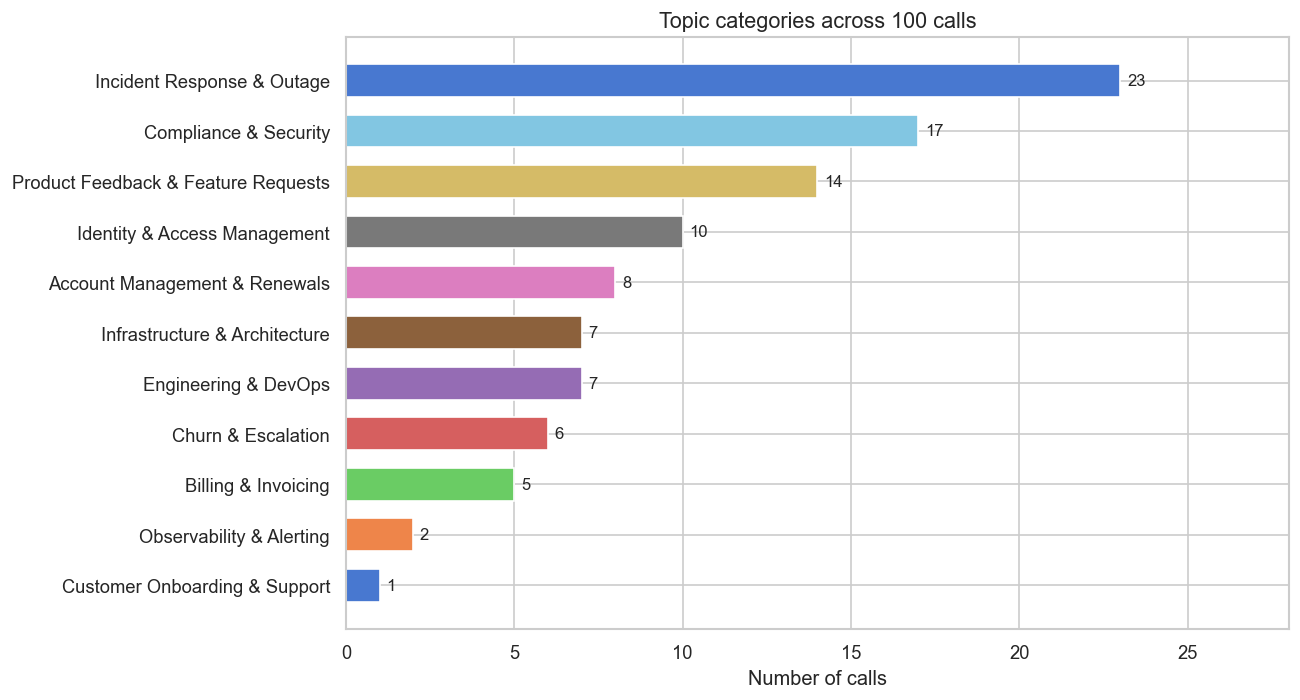

Chart saved: output_02_topic_categories.png

=== Example calls per category (top 4) ===

[Incident Response & Outage]
  internal | Detect Outage - Remediation Plan Review
  Megan, Raj, and Brian convened on day three of an ongoing outage affecting the Detect product's event processing pipeline. Raj explained that a single point of failure in the event...
  external | Aegis / Quantum Edge - Renewal Concerns
  Maria Santos met with Brianna Foster and Leo Marquez to address a serious six-hour outage on March 10-11 that caused a loss of visibility in Aegis Detect, breaching their 99.5% upt...

[Compliance & Security]
  external | Aegis / Redwood Clinical - ISO 27001 Preparation
  Daniel Okafor and solutions architect Kevin O'Brien met with Thomas Hargrove of Redwood to introduce Comply v2 and discuss support for their ISO 27001 certification journey. Thomas...
  internal | SOC 2 Audit Preparation - Internal
  Raj Kapoor convened a meeting with Tyler, Ravi, Brian, and Mike to prepare for an

In [13]:
cat_counts = df["primary_category"].value_counts()
fig, ax    = plt.subplots(figsize=(11, 6))
palette    = sns.color_palette("muted", len(cat_counts))
bars       = ax.barh(cat_counts.index[::-1], cat_counts.values[::-1], color=palette, height=0.65)
for bar in bars:
    ax.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2, str(int(bar.get_width())), va="center", fontsize=10)
ax.set_title("Topic categories across 100 calls", fontsize=13)
ax.set_xlabel("Number of calls")
ax.set_xlim(0, cat_counts.max()+5)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"output_02_topic_categories.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: output_02_topic_categories.png")

print("\n=== Example calls per category (top 4) ===")
for cat in df["primary_category"].value_counts().head(4).index:
    print(f"\n[{cat}]")
    for _, row in df[df["primary_category"]==cat][["title","call_type","summary"]].head(2).iterrows():
        print(f"  {row['call_type']} | {row['title']}")
        print(f"  {row['summary'][:180]}...")

## Cell 9 — Phase 4: Overall Sentiment Distribution

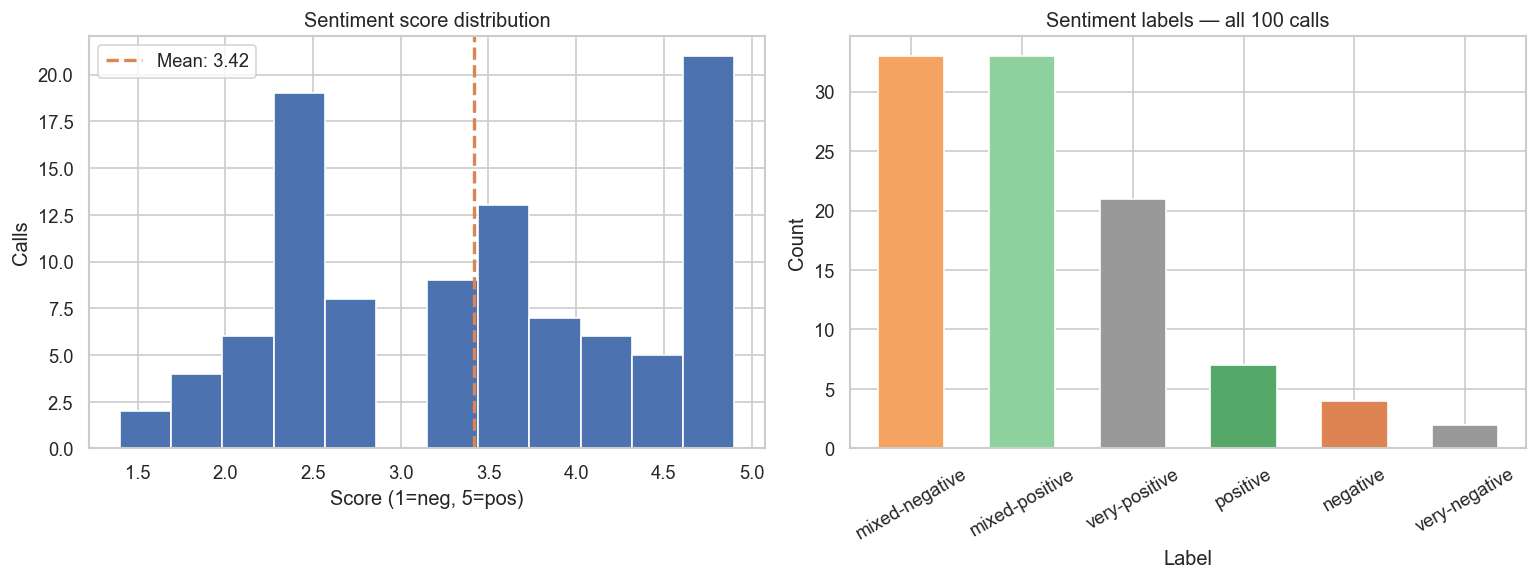

Chart saved: output_03_sentiment_overall.png


In [14]:
fig, axes  = plt.subplots(1, 2, figsize=(13, 5))
mean_score = df["sentiment_score"].mean()
ax = axes[0]
df["sentiment_score"].dropna().hist(bins=12, ax=ax, color="#4C72B0", edgecolor="white")
ax.axvline(mean_score, color="#DD8452", linestyle="--", linewidth=2, label=f"Mean: {mean_score:.2f}")
ax.set_title("Sentiment score distribution", fontsize=12)
ax.set_xlabel("Score (1=neg, 5=pos)"); ax.set_ylabel("Calls"); ax.legend()
ax = axes[1]
slc = df["overall_sentiment"].value_counts()
cm  = {"positive":"#55A868","mixed-positive":"#8FD19E","neutral":"#C7C7C7","mixed-negative":"#F4A460","negative":"#DD8452"}
slc.plot(kind="bar", ax=ax, color=[cm.get(l,"#999") for l in slc.index], width=0.6)
ax.set_title("Sentiment labels — all 100 calls", fontsize=12)
ax.set_xlabel("Label"); ax.set_ylabel("Count"); ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"output_03_sentiment_overall.png", dpi=150, bbox_inches="tight")
plt.show(); print("Chart saved: output_03_sentiment_overall.png")

## Cell 10 — Sentiment by Call Type

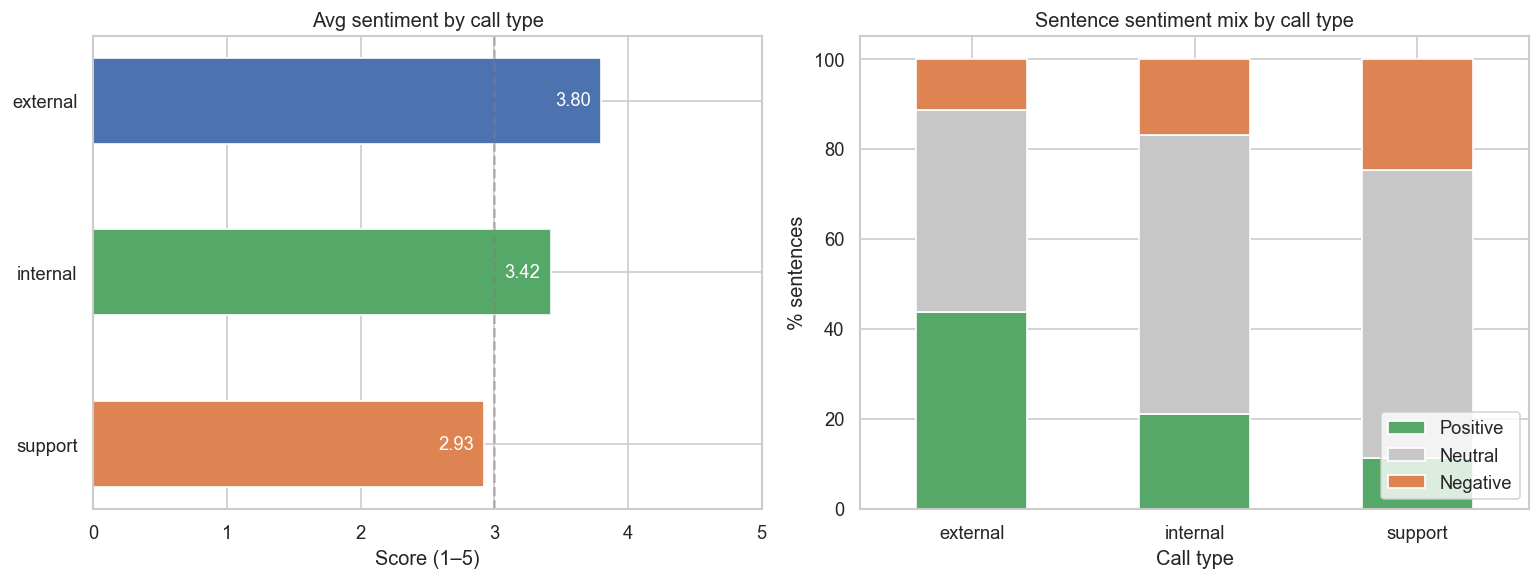

Chart saved: output_04_sentiment_by_calltype.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
avg_score = df.groupby("call_type")["sentiment_score"].mean().sort_values()
ax = axes[0]
bars = ax.barh(avg_score.index, avg_score.values, color=[color_map.get(c,"#999") for c in avg_score.index], height=0.5)
for bar in bars:
    ax.text(bar.get_width()-0.08, bar.get_y()+bar.get_height()/2, f"{bar.get_width():.2f}", va="center", ha="right", color="white", fontsize=11)
ax.axvline(3, color="gray", linestyle="--", alpha=0.5); ax.set_xlim(0,5)
ax.set_title("Avg sentiment by call type", fontsize=12); ax.set_xlabel("Score (1–5)")
ax = axes[1]
df.groupby("call_type")[["pct_positive","pct_neutral","pct_negative"]].mean().plot(
    kind="bar", ax=ax, stacked=True, color=["#55A868","#C7C7C7","#DD8452"], width=0.5)
ax.set_title("Sentence sentiment mix by call type", fontsize=12)
ax.set_xlabel("Call type"); ax.set_ylabel("% sentences"); ax.tick_params(axis="x",rotation=0)
ax.legend(["Positive","Neutral","Negative"], loc="lower right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"output_04_sentiment_by_calltype.png", dpi=150, bbox_inches="tight")
plt.show(); print("Chart saved: output_04_sentiment_by_calltype.png")

## Cell 11 — Sentiment by Topic Category

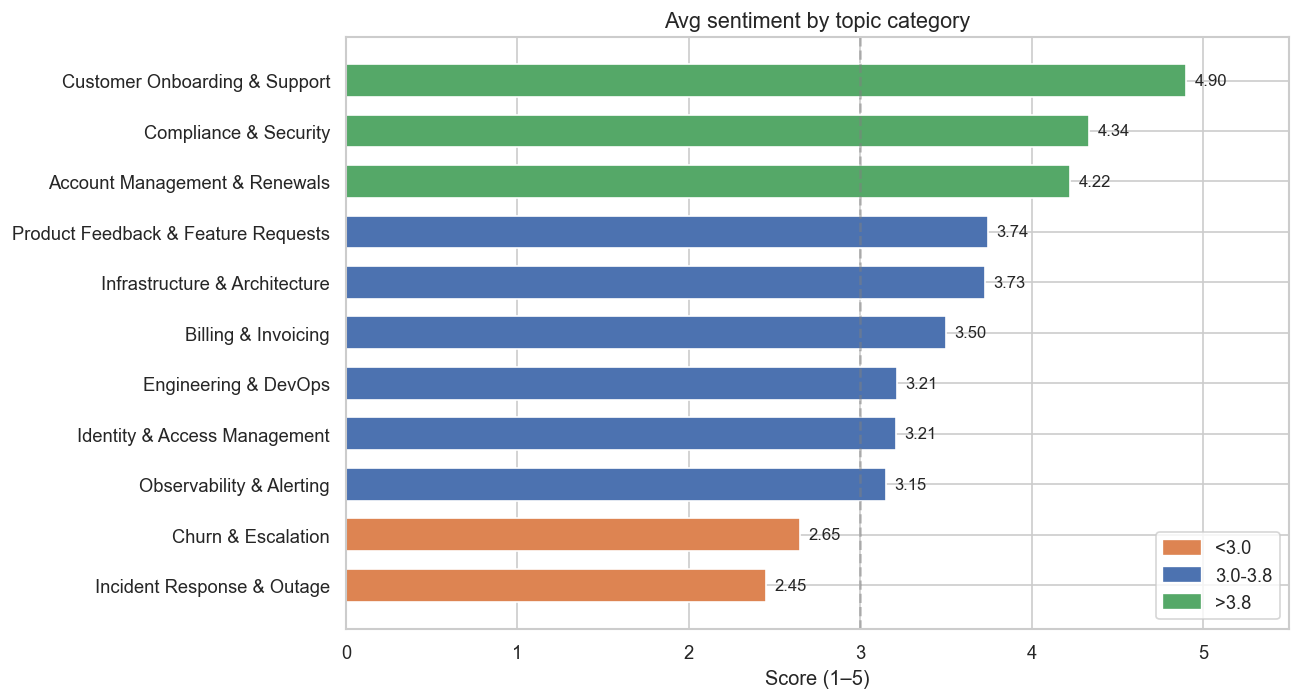

Chart saved: output_05_sentiment_by_category.png


In [16]:
cat_sentiment = df.groupby("primary_category")["sentiment_score"].mean().sort_values()
fig, ax = plt.subplots(figsize=(11, 6))
bar_colors = ["#DD8452" if v<3 else "#4C72B0" if v<3.8 else "#55A868" for v in cat_sentiment.values]
ax.barh(cat_sentiment.index, cat_sentiment.values, color=bar_colors, height=0.65)
for i, (idx, val) in enumerate(cat_sentiment.items()):
    ax.text(val+0.05, i, f"{val:.2f}", va="center", fontsize=10)
ax.axvline(3, color="gray", linestyle="--", alpha=0.5)
ax.set_title("Avg sentiment by topic category", fontsize=13); ax.set_xlabel("Score (1–5)"); ax.set_xlim(0, 5.5)
ax.legend(handles=[mpatches.Patch(color=c,label=l) for c,l in [("#DD8452","<3.0"),("#4C72B0","3.0-3.8"),("#55A868",">3.8")]], loc="lower right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"output_05_sentiment_by_category.png", dpi=150, bbox_inches="tight")
plt.show(); print("Chart saved: output_05_sentiment_by_category.png")

## Cell 12 — Sentiment Arc

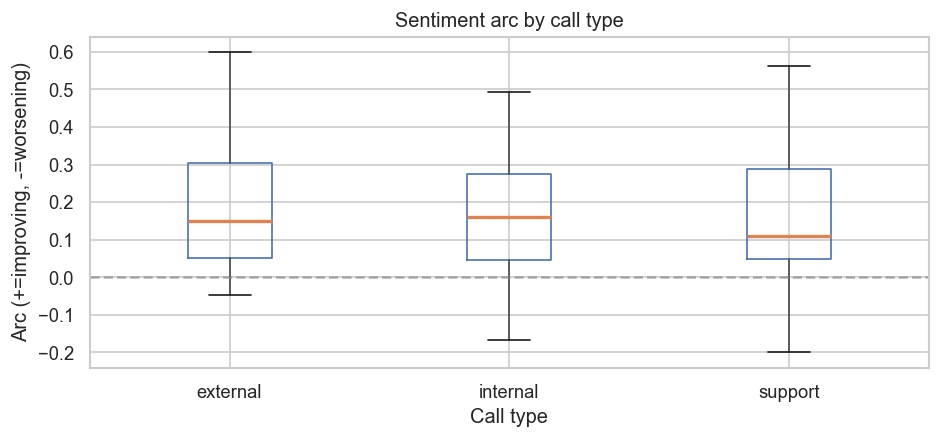

Chart saved: output_06_sentiment_arc.png


In [17]:
def compute_sentiment_arc(sentences):
    if len(sentences) < 4: return 0.0
    sm = {"positive":1,"neutral":0,"negative":-1}
    scores = [sm.get(s.get("sentimentType","neutral"),0) for s in sentences]
    mid = len(scores)//2
    return round(sum(scores[mid:])/(len(scores)-mid) - sum(scores[:mid])/mid, 3)

df["sentiment_arc"] = df["sentences"].apply(compute_sentiment_arc)
fig, ax = plt.subplots(figsize=(8, 4))
df.boxplot(column="sentiment_arc", by="call_type", ax=ax,
           boxprops=dict(color="#4C72B0"), medianprops=dict(color="#DD8452", linewidth=2))
ax.axhline(0, color="gray", linestyle="--", alpha=0.6)
ax.set_title("Sentiment arc by call type", fontsize=12)
ax.set_xlabel("Call type"); ax.set_ylabel("Arc (+=improving, -=worsening)")
plt.suptitle("")
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"output_06_sentiment_arc.png", dpi=150, bbox_inches="tight")
plt.show(); print("Chart saved: output_06_sentiment_arc.png")

## Cell 13 — Phase 5A: Agent Performance (compute)

In [18]:
support_df = df[df["call_type"]=="support"].copy()

def get_agent_name(row):
    for email in row["all_emails"]:
        if INTERNAL_DOMAIN in email.lower():
            return email.split("@")[0].replace("."," ").title()
    return "Unknown"

def get_agent_talk_ratio(row):
    tt = row["speaker_talk_time"]
    if not tt: return 0.0
    total = sum(tt.values())
    if total == 0: return 0.0
    agent = get_agent_name(row)
    return round(sum(v for k,v in tt.items() if agent.lower() in k.lower())/total, 3)

support_df["agent_name"]       = support_df.apply(get_agent_name, axis=1)
support_df["agent_talk_ratio"] = support_df.apply(get_agent_talk_ratio, axis=1)

agent_stats = support_df.groupby("agent_name").agg(
    num_calls=("meeting_id","count"), avg_sentiment=("sentiment_score","mean"),
    avg_arc=("sentiment_arc","mean"), avg_duration_min=("duration_min","mean"),
    avg_action_items=("num_action_items","mean"), avg_talk_ratio=("agent_talk_ratio","mean")
).round(2).reset_index()
agent_stats = agent_stats[agent_stats["num_calls"]>=2].sort_values("avg_sentiment", ascending=False)

print("=== Agent Performance Scorecard ===")
print(agent_stats.to_string(index=False))

=== Agent Performance Scorecard ===
     agent_name  num_calls  avg_sentiment  avg_arc  avg_duration_min  avg_action_items  avg_talk_ratio
    Priya Patel          4           3.38     0.18             15.20              4.00            0.50
      David Kim          7           3.17     0.14             18.53              3.86            0.50
   Maria Santos          3           3.10     0.26             38.23              4.00            0.49
     Sarah Chen          9           2.94     0.09             20.76              4.00            0.46
Marcus Williams          3           2.67     0.24             15.03              4.00            0.44
  Elena Vasquez          5           2.24     0.13             16.52              4.00            0.47


## Cell 14 — Agent Performance Chart

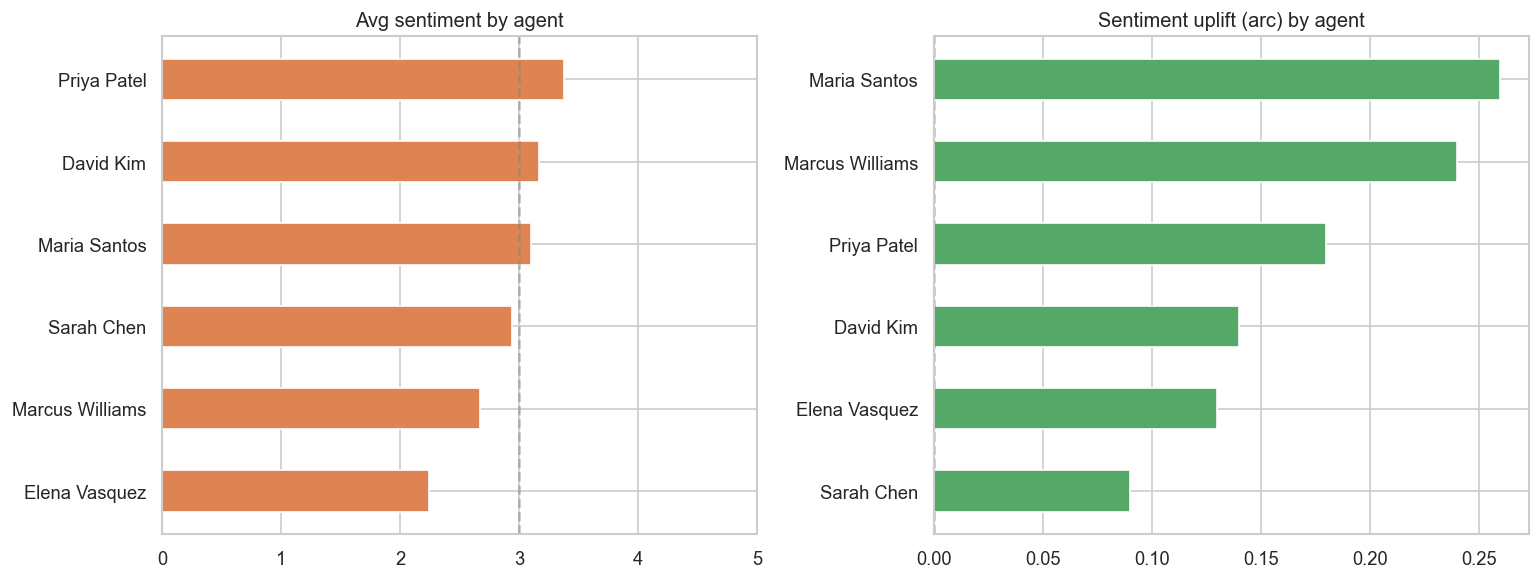

Chart saved: output_07_agent_performance.png


In [19]:
if len(agent_stats) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    srt = agent_stats.sort_values("avg_sentiment")
    axes[0].barh(srt["agent_name"], srt["avg_sentiment"],
                 color=["#55A868" if v>=3.5 else "#DD8452" for v in srt["avg_sentiment"]], height=0.5)
    axes[0].axvline(3, color="gray", linestyle="--", alpha=0.5)
    axes[0].set_title("Avg sentiment by agent", fontsize=12); axes[0].set_xlim(0,5)
    srt_arc = agent_stats.sort_values("avg_arc")
    axes[1].barh(srt_arc["agent_name"], srt_arc["avg_arc"],
                 color=["#55A868" if v>=0 else "#DD8452" for v in srt_arc["avg_arc"]], height=0.5)
    axes[1].axvline(0, color="gray", linestyle="--", alpha=0.5)
    axes[1].set_title("Sentiment uplift (arc) by agent", fontsize=12)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR/"output_07_agent_performance.png", dpi=150, bbox_inches="tight")
    plt.show(); print("Chart saved: output_07_agent_performance.png")
else:
    print("Not enough agents with 2+ calls.")

## Cell 15 — Phase 5B: Feature Gap Detection

In [20]:
def extract_gaps_from_key_moments(row):
    return [{
        "feature_request":m.get("text","")[:120], "speaker":m.get("speaker","Unknown"),
        "urgency":"medium", "source":"key_moment",
        "meeting_id":row["meeting_id"], "title":row["title"], "call_type":row["call_type"]
    } for m in row["key_moments"] if m.get("type")=="feature_gap"]

def extract_gaps_from_llm(row):
    sentences = row["sentences"]
    if not sentences: return []
    txt = "\n".join(f"{s.get('speaker_name','?')}: {s.get('sentence','')}" for s in sentences)[:1200]
    prompt = f"""Find feature requests or product gaps in this B2B SaaS customer call.
Return ONLY a JSON array. Each item: feature_request (max 15 words), speaker, urgency (high/medium/low).
If nothing found return: []
No explanation. JSON only.

TRANSCRIPT:
{txt}

JSON array:"""
    gaps = safe_parse_json_array(call_llm(prompt, num_ctx=2048))
    for g in (gaps if isinstance(gaps,list) else []):
        g.update({"source":"llm","meeting_id":row["meeting_id"],"title":row["title"],"call_type":row["call_type"]})
    return gaps if isinstance(gaps,list) else []

customer_calls = df[df["call_type"].isin(["support","external"])].copy()
all_gaps = [g for _, row in customer_calls.iterrows() for g in extract_gaps_from_key_moments(row)]
print(f"Step 1: {len(all_gaps)} pre-flagged gaps from key_moments.")

print("\nStep 2: LLM scan on 15 calls...")
for _, row in tqdm(customer_calls.head(15).iterrows(), total=15):
    all_gaps.extend(extract_gaps_from_llm(row))

gaps_df = pd.DataFrame(all_gaps).drop_duplicates(subset=["feature_request","meeting_id"]) if all_gaps else pd.DataFrame()
print(f"\nTotal feature gap signals: {len(gaps_df)}")
if not gaps_df.empty:
    cols = [c for c in ["feature_request","speaker","urgency","call_type","source"] if c in gaps_df.columns]
    print(gaps_df[cols].to_string(index=False))

Step 1: 36 pre-flagged gaps from key_moments.

Step 2: LLM scan on 15 calls...


100%|██████████| 15/15 [06:59<00:00, 27.98s/it]


Total feature gap signals: 69
                                                                                                         feature_request         speaker urgency call_type     source
                 Gregory requests proactive seat-count threshold alerts to avoid discovering overages on future invoices    Gregory Fisk  medium   support key_moment
Wayne asks about SOC 2 compliance reporting, signaling potential expansion opportunity with the Aegis Comply add-on modu    Wayne Keller  medium  external key_moment
Sarah confirms that granular file-level restore is not currently supported in Aegis Protect, validating Jason's suspicio      Sarah Chen  medium   support key_moment
                        James reveals that on-demand reporting is not yet available but is coming in an upcoming release  James Mitchell  medium  external key_moment
Julia challenges the platform's architecture, pointing out that a single component failure took down the entire monitori      Julia Tran  m

## Cell 16 — Feature Gap Chart

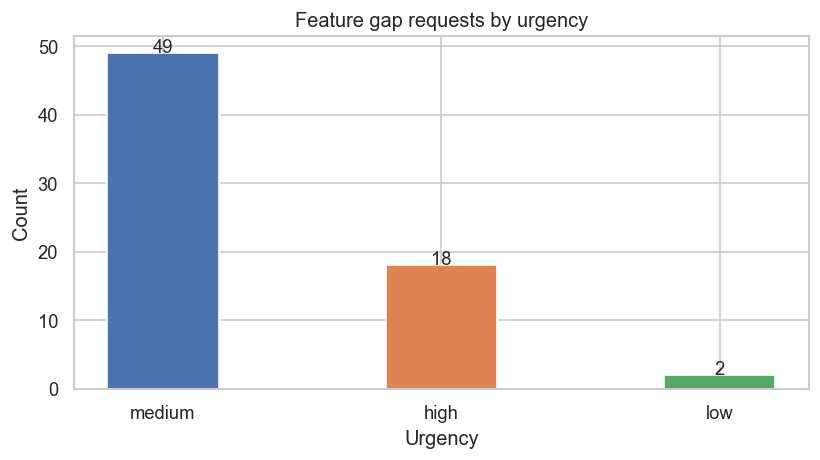

Chart saved: output_08_feature_gaps.png


In [21]:
if not gaps_df.empty and "urgency" in gaps_df.columns:
    uc = gaps_df["urgency"].value_counts()
    uco = {"high":"#DD8452","medium":"#4C72B0","low":"#55A868"}
    fig, ax = plt.subplots(figsize=(7,4))
    bars = ax.bar(uc.index, uc.values, color=[uco.get(u,"#999") for u in uc.index], width=0.4)
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1, str(int(bar.get_height())), ha="center", fontsize=11)
    ax.set_title("Feature gap requests by urgency", fontsize=12)
    ax.set_xlabel("Urgency"); ax.set_ylabel("Count")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR/"output_08_feature_gaps.png", dpi=150, bbox_inches="tight")
    plt.show(); print("Chart saved: output_08_feature_gaps.png")
else:
    print("No feature gaps found.")

## Cell 17 — Phase 5C: Churn Risk Scoring

In [22]:
ESCALATION_KW = ["escalat","churn","cancel","unhappy","frustrated","disappointed",
                 "not acceptable","unacceptable","terrible","outage","down","broken",
                 "sentinelshield","competitor","evaluation","switching","vendor review"]

def compute_churn_risk(row):
    score, reasons = 0, []
    if any("billing" in t or "invoice" in t or "overage" in t for t in row["topics"]):
        score+=2; reasons.append("billing dispute")
    if row["sentiment_score"] is not None and row["sentiment_score"] < 3:
        score+=2; reasons.append(f"low sentiment ({row['sentiment_score']})")
    text = (row["title"]+" "+row["summary"]).lower()
    matched = [kw for kw in ESCALATION_KW if kw in text]
    if matched: score+=2; reasons.append(f"escalation: {', '.join(matched[:3])}")
    cm = [m for m in row["key_moments"] if m.get("type")=="churn_signal"]
    if cm: score+=2; reasons.append(f"{len(cm)} churn signal(s)")
    if row["sentiment_arc"] < -0.05: score+=1; reasons.append("worsening arc")
    if row["num_action_items"] > 3: score+=1; reasons.append(f"{row['num_action_items']} action items")
    return {"churn_risk_score":score, "churn_risk_level":"high" if score>=4 else "medium" if score>=2 else "low", "risk_reasons":reasons}

mask = df["call_type"].isin(["support","external"])
customer_risk_df = df[mask].join(df[mask].apply(compute_churn_risk, axis=1, result_type="expand"))

print("=== Churn Risk Distribution ===")
print(customer_risk_df["churn_risk_level"].value_counts().to_string())
print("\n=== Top High Risk Accounts ===")
print(customer_risk_df[customer_risk_df["churn_risk_level"]=="high"].sort_values("churn_risk_score",ascending=False)[["title","churn_risk_score","sentiment_score","risk_reasons"]].head(10).to_string(index=False))

=== Churn Risk Distribution ===
churn_risk_level
high      36
medium    17
low       17

=== Top High Risk Accounts ===
                                                              title  churn_risk_score  sentiment_score                                                                                                          risk_reasons
    Support Case #8179 - Clearwater Medical Overage Charges Dispute                10              2.4 [billing dispute, low sentiment (2.4), escalation: escalat, outage, 1 churn signal(s), worsening arc, 4 action items]
   Support Case #6977 - Brightpath Commerce Slow Backup Performance                 7              2.8                                         [low sentiment (2.8), escalation: escalat, 1 churn signal(s), 4 action items]
          Aegis / Meridian Capital - Service Reliability Discussion                 7              2.4              [low sentiment (2.4), escalation: outage, sentinelshield, competitor, 1 churn signal(s), 4 action ite

## Cell 18 — Churn Risk Chart

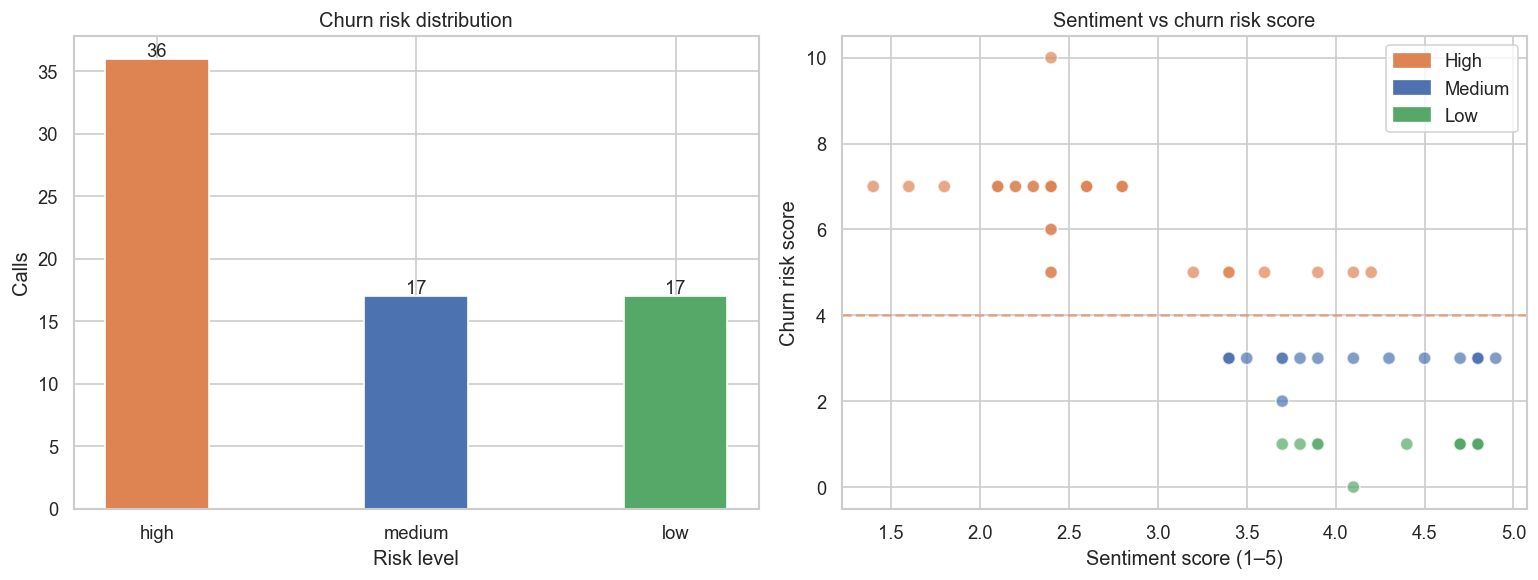

Chart saved: output_09_churn_risk.png


In [23]:
rc = {"high":"#DD8452","medium":"#4C72B0","low":"#55A868"}
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
risk_counts = customer_risk_df["churn_risk_level"].value_counts()
bars = axes[0].bar(risk_counts.index, risk_counts.values, color=[rc.get(l,"#999") for l in risk_counts.index], width=0.4)
for bar in bars:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2, str(int(bar.get_height())), ha="center", fontsize=11)
axes[0].set_title("Churn risk distribution", fontsize=12); axes[0].set_xlabel("Risk level"); axes[0].set_ylabel("Calls")
axes[1].scatter(customer_risk_df["sentiment_score"].fillna(3), customer_risk_df["churn_risk_score"],
               c=[rc.get(l,"#999") for l in customer_risk_df["churn_risk_level"]], alpha=0.7, s=60, edgecolors="white")
axes[1].axhline(4, color="#DD8452", linestyle="--", alpha=0.6)
axes[1].set_title("Sentiment vs churn risk score", fontsize=12)
axes[1].set_xlabel("Sentiment score (1–5)"); axes[1].set_ylabel("Churn risk score")
axes[1].legend(handles=[mpatches.Patch(color=v,label=k.title()) for k,v in rc.items()])
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"output_09_churn_risk.png", dpi=150, bbox_inches="tight")
plt.show(); print("Chart saved: output_09_churn_risk.png")

## Cell 19 — Final Summary

In [24]:
charts = sorted(OUTPUT_DIR.glob("output_*.png"))
print(f"Output charts generated: {len(charts)}")
for c in charts: print(f"  OK {c.name}")
print()
print("="*65)
print("  TRANSCRIPT INTELLIGENCE — KEY FINDINGS SUMMARY")
print("="*65)
print(f"""
DATASET
  Total calls      : {len(df)}
  Call types       : {dict(df['call_type'].value_counts())}
  Avg duration     : {df['duration_min'].mean():.1f} min

TASK 1 — TOPIC CATEGORISATION
  Unique tags      : {len(unique_tags)}
  Macro-categories : {df['primary_category'].nunique()}
  Top category     : {df['primary_category'].value_counts().index[0]} ({df['primary_category'].value_counts().iloc[0]} calls)

TASK 2 — SENTIMENT
  Avg score        : {df['sentiment_score'].mean():.2f} / 5.0
  Most positive    : {df.groupby('call_type')['sentiment_score'].mean().idxmax()}
  Most negative    : {df.groupby('call_type')['sentiment_score'].mean().idxmin()}
  Worsening arc    : {(df['sentiment_arc']<-0.05).sum()} calls ({(df['sentiment_arc']<-0.05).mean()*100:.0f}%)

TASK 3 — BONUS INSIGHTS
  Agents scored    : {len(agent_stats)} agents, {agent_stats['num_calls'].sum() if not agent_stats.empty else 0} calls
  Feature gaps     : {len(gaps_df)} signals
  High churn risk  : {(customer_risk_df['churn_risk_level']=='high').sum()} of {len(customer_risk_df)} customer calls
""")
print("="*65)

Output charts generated: 9
  OK output_01_call_type_distribution.png
  OK output_02_topic_categories.png
  OK output_03_sentiment_overall.png
  OK output_04_sentiment_by_calltype.png
  OK output_05_sentiment_by_category.png
  OK output_06_sentiment_arc.png
  OK output_07_agent_performance.png
  OK output_08_feature_gaps.png
  OK output_09_churn_risk.png

  TRANSCRIPT INTELLIGENCE — KEY FINDINGS SUMMARY

DATASET
  Total calls      : 100
  Call types       : {'external': np.int64(39), 'support': np.int64(31), 'internal': np.int64(30)}
  Avg duration     : 30.3 min

TASK 1 — TOPIC CATEGORISATION
  Unique tags      : 351
  Macro-categories : 11
  Top category     : Incident Response & Outage (23 calls)

TASK 2 — SENTIMENT
  Avg score        : 3.42 / 5.0
  Most positive    : external
  Most negative    : support
  Worsening arc    : 5 calls (5%)

TASK 3 — BONUS INSIGHTS
  Agents scored    : 6 agents, 31 calls
  Feature gaps     : 69 signals
  High churn risk  : 36 of 70 customer calls



In [25]:
# Quick results summary — paste output here for review
print("=== PIPELINE RESULTS ===")
print(f"Calls loaded          : {len(df)}")
print(f"Call types            : {dict(df['call_type'].value_counts())}")
print(f"Categories            : {df['primary_category'].nunique()}")
print(f"Top category          : {df['primary_category'].value_counts().index[0]} ({df['primary_category'].value_counts().iloc[0]} calls)")
print(f"Other %               : {(df['primary_category']=='Other').mean()*100:.0f}%")
print(f"Avg sentiment score   : {df['sentiment_score'].mean():.2f}")
print(f"Most negative type    : {df.groupby('call_type')['sentiment_score'].mean().idxmin()}")
print(f"Most positive type    : {df.groupby('call_type')['sentiment_score'].mean().idxmax()}")
print(f"Calls worsening arc   : {(df['sentiment_arc']<-0.05).sum()}")
print(f"Agents scored         : {len(agent_stats)}")
print(f"Feature gaps found    : {len(gaps_df)}")
print(f"High churn risk calls : {(customer_risk_df['churn_risk_level']=='high').sum()}")
print(f"Charts saved          : {len(list(OUTPUT_DIR.glob('output_*.png')))}")

=== PIPELINE RESULTS ===
Calls loaded          : 100
Call types            : {'external': np.int64(39), 'support': np.int64(31), 'internal': np.int64(30)}
Categories            : 11
Top category          : Incident Response & Outage (23 calls)
Other %               : 0%
Avg sentiment score   : 3.42
Most negative type    : support
Most positive type    : external
Calls worsening arc   : 5
Agents scored         : 6
Feature gaps found    : 69
High churn risk calls : 36
Charts saved          : 9
